In [1]:
# Single-row floe properties with the seasonal evolution of FSD and FSD slope

In [41]:
import os
import pandas as pd
import ultraplot as pplt
import numpy as np

# Load floe data
floe_lib_clean = {}
for file in os.listdir('../data/floe_tracker/ift_floe_property_tables/with_nsidc/'):
    if 'csv' in file: 
        year = int(file.replace('.csv', '').split('_')[-1])
        floe_lib_clean[year] = pd.read_csv('../data/floe_tracker/ift_floe_property_tables/with_nsidc/' + file,
                                         index_col=0, dtype={'classification': str})
        floe_lib_clean[year]['datetime'] = pd.to_datetime(floe_lib_clean[year]['datetime'])

df = pd.concat(floe_lib_clean).reset_index()
df = df.loc[(df.datetime.dt.dayofyear >= 91) & (df.datetime.dt.dayofyear <= 258)]
df['perim_km'] = df.perimeter*.25
df['area_km'] = df.area*.25*.25
df['area_adj_km'] = (np.sqrt(df.area) + 8)**2*.25*.25 # Pixel shift minimizes error against manual
df['doy'] = df.datetime.dt.dayofyear
df['year'] = df.datetime.dt.year


df['band_1_reflectance'] = df['tc_channel0']/255
df['month'] = df.datetime.dt.month
df['n'] = df.groupby('datetime').transform(lambda x: len(x))['area']
df['length_scale_km'] = df['area_adj_km']**0.5


In [43]:
### Load FSD data
results = []
for year in range(2003, 2021):
    results.append(pd.read_csv('../data/floe_tracker/ift_fsd_tables/ift_fsd_table_{y}.csv'.format(y=year), parse_dates=['date']))
results = pd.concat(results, axis=0)
results_alt = pd.read_csv('../data/floe_tracker/ift_fsd_tables/ift_fsd_table_all_years_by_DOY.csv')
dr = pd.date_range('2020-04-01', '2020-09-01', freq='1MS')
dr_doy = results.groupby('month').mean()['doy']


In [44]:
# Panel 1: Add floe count per image by day of year
# Consider separating the shape, reflectance data
# Consider adding the sea ice extent as an overlay to the ice concentration
count_range = df.groupby(['year', 'doy']).count().pivot_table(
                index='year', columns='doy', values='area').quantile(
                    [0.1, 0.25, 0.5, 0.75, 0.9], axis=0)
smoothed_count_range.columns = ['p10', 'p25', 'med', 'p75', 'p90']

In [68]:
# Select a sample of dates to plot by selecting 
# a date from each month and year at random, conditioned on at least
# 200 floes being present.

counts_by_date = df.groupby('datetime').count()['floe_id']
counts_by_date = pd.DataFrame({'year': counts_by_date.index.year,
              'month': counts_by_date.index.month,
              'datetime': counts_by_date.index,
              'n': counts_by_date.values})
counts_by_date = counts_by_date.loc[counts_by_date['n'] > 200, :]
plot_samples = counts_by_date.groupby(['year', 'month']).sample(random_state=150)
plot_doys = plot_samples.datetime.dt.dayofyear.unique()
plot_doys.sort()

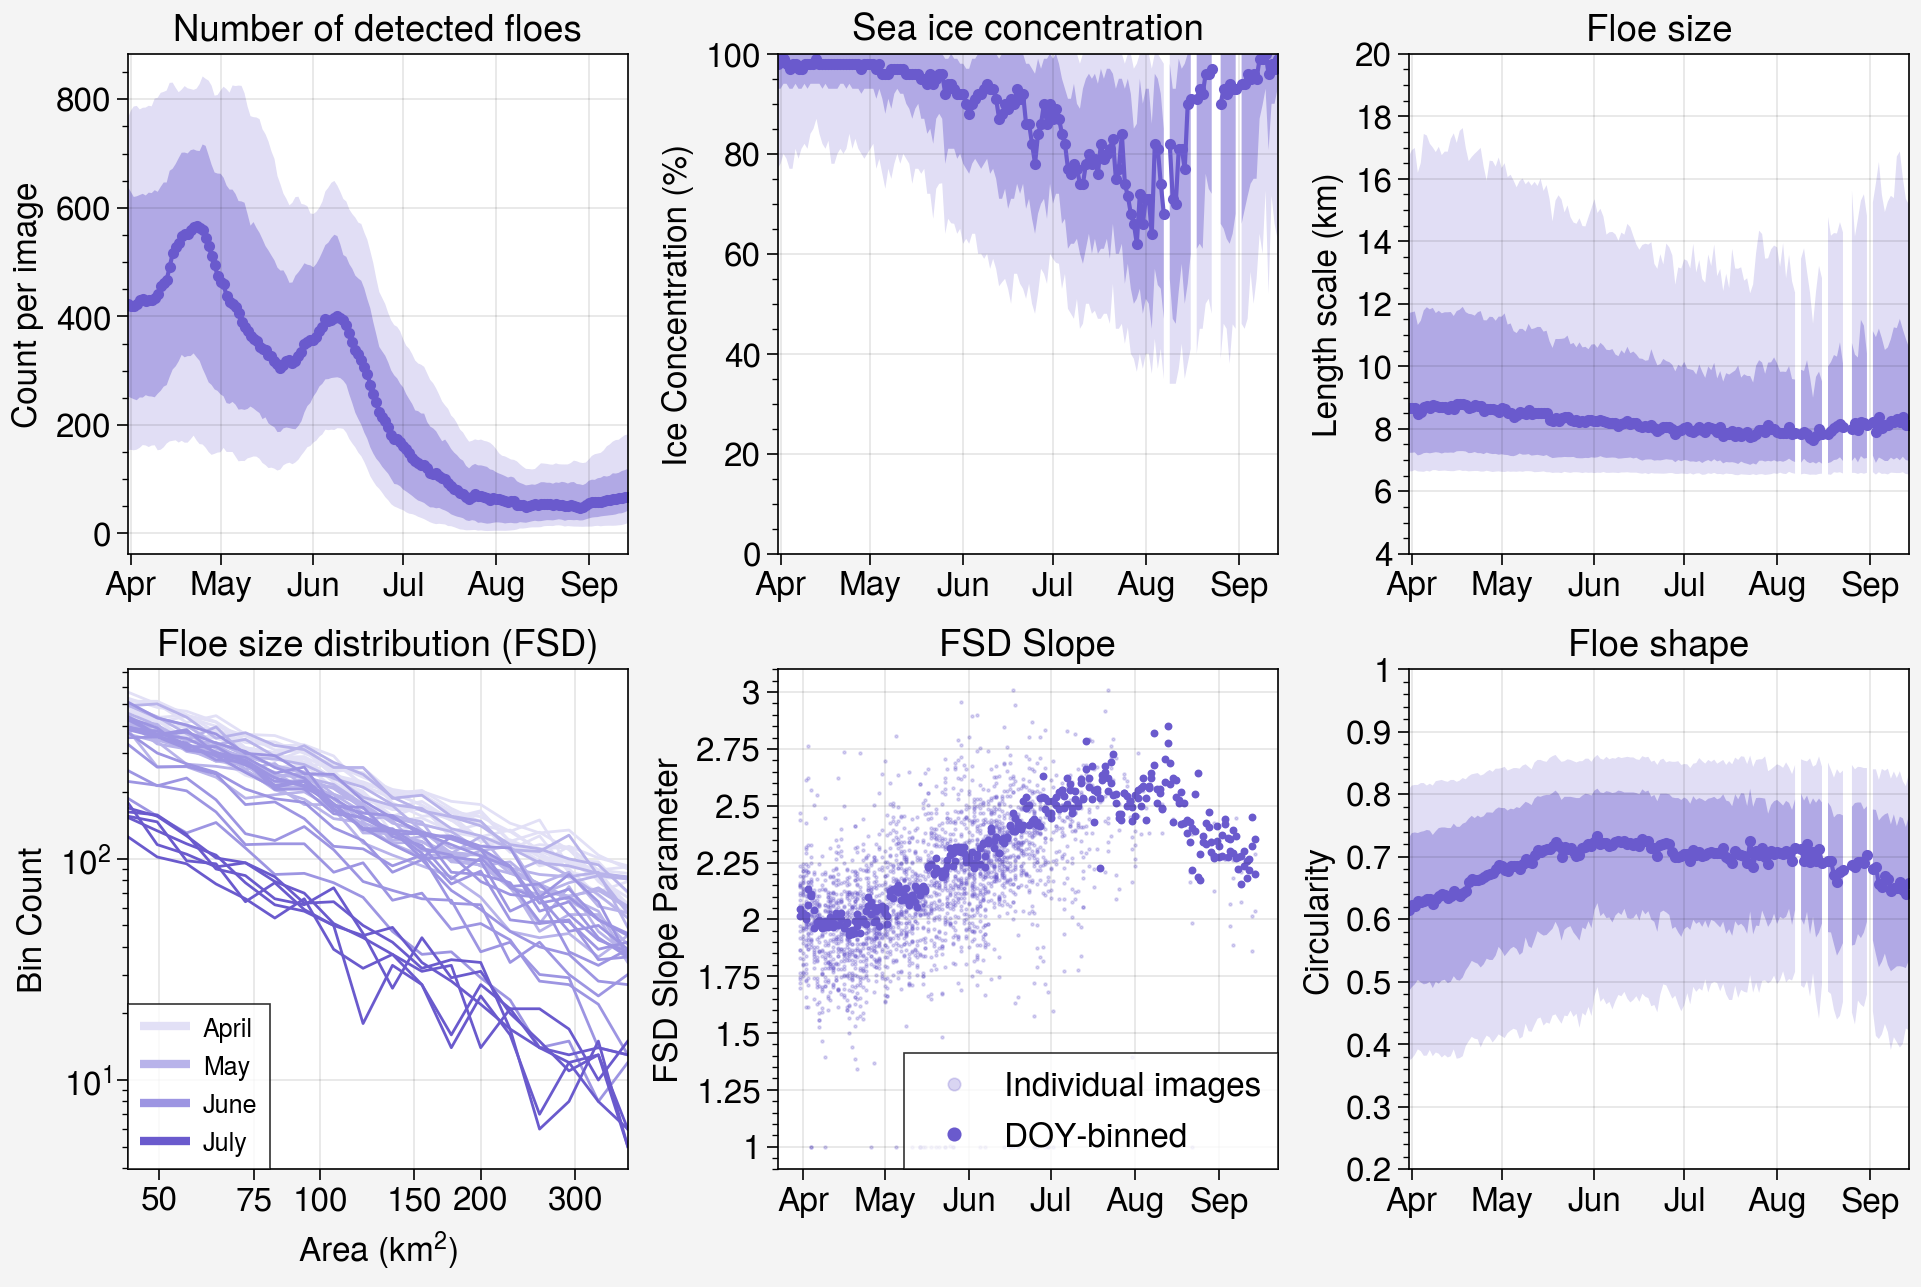

In [202]:
df['sea_ice_concentration'] = 100 * df['nsidc_sic']

fig, axs = pplt.subplots(ncols=3, share=False, nrows=2)

idx = df.n > 30
# idx = idx & df.nsidc_sic.between(0.15, 0.85)
idx = idx & df.final_classification

# Plot floe count
# 'circularity', 'band_1_reflectance', 
ax = axs[0]
ax.plot(smoothed_count_range['med'], 
            fadedata=[smoothed_count_range['p90'],
                      smoothed_count_range['p10']],
            shadedata=[smoothed_count_range['p75'],
                      smoothed_count_range['p25']],
            marker='.', color='slateblue')
ax.format(ylabel='Floe Count',
          xlocator=dr.dayofyear,
          xformatter=[d.strftime('%b') for d in dr],
          xlabel='', fontsize=12)


ylims = {'sea_ice_concentration': (0, 100),
         'length_scale_km': (4, 20), 
         'circularity': (0.2, 1),
         'band_1_reflectance': (0.5, 1),
         'alpha_tpl': (0.9, 3.1)}

for col, var in zip([1, 2, 5],
                          ['sea_ice_concentration', 'length_scale_km', 'circularity']):
    # shade data
    ax = axs[col]
    n = df.loc[idx, [var, 'doy']].groupby('doy').count()
    med = df.loc[idx, [var, 'doy']].groupby('doy').median().where(n > 500)
    p90 = df.loc[idx, [var, 'doy']].groupby('doy').quantile(0.90).where(n > 500)
    p10 = df.loc[idx, [var, 'doy']].groupby('doy').quantile(0.10).where(n > 500)
    p75 = df.loc[idx, [var, 'doy']].groupby('doy').quantile(0.75).where(n > 500)
    p25 = df.loc[idx, [var, 'doy']].groupby('doy').quantile(0.25).where(n > 500)
    ax.plot(med[var], fadedata=[p90[var], p10[var]],
            shadedata=[p75[var], p25[var]], marker='.', color='slateblue')
    ax.format(ylabel=var.replace('_', ' '),
              xlocator=dr.dayofyear,
              xformatter=[d.strftime('%b') for d in dr],
              xlabel='', fontsize=12, ylim=ylims[var])


ax = axs[3]
slate_colors = [c['color'] for c in pplt.Cycle('slateblue', 10)]
colors = {month: color for month, color in zip([4, 5, 6, 7],
                                               [slate_colors[0], slate_colors[3], slate_colors[5],
                                                'slateblue'])}
bins = np.logspace(np.log10(36), np.log10(400), 20)
bin_centers = 0.5 * (bins[0:-1] + bins[1:])

for day_of_year in plot_doys:
    data = df.loc[df.datetime.dt.dayofyear == day_of_year, :]
    month = data.datetime.dt.month.values[0]
    x, y = np.histogram(data['area_km'], bins=bins, density=False)
    ax.plot(bin_centers[1:], x[1:], marker='', c=colors[month], lw=1)
    ax.format(yscale='log', xscale='log', xlocator=[50, 75, 100, 150, 200, 300],
              xminorticks='none', yformatter='log', fontsize=12,
              ylabel='Bin Count', xlabel='Area (km$^2$)', title='Floe size distribution (FSD)')


h = [ax.plot([],[], lw=3, ls='-', color=colors[m]) for m in [4, 5, 6, 7]]
ax.legend(h, ['April', 'May', 'June', 'July'], ncols=1, loc='ll')



ax = axs[4]
n_threshold = 1 # check what this one is doing -- is it just to see if the month has anything in it?
month_threshold = 300
var = 'alpha_tpl'
time_idx = (results.month != 3) & (results.month <= 9)
df_pivot = results.loc[time_idx & (results.n > n_threshold)].pivot_table(index='date', values=variable, columns='month')
month_counts = df_pivot.notnull().sum() 
month_idx = [m for m in month_counts.index if month_counts[m] > month_threshold]
_ = ax.scatter(results.loc[results.n > n_threshold].date.dt.dayofyear,
               results.loc[results.n > n_threshold, var],
               marker='o', ms=1, zorder=0,
               label='Individual images', color='slateblue', alpha=0.25)
_ = ax.scatter(results_alt.doy, results_alt[var],
               marker='o', ms=5, zorder=0,
               color='slateblue', label='DOY-binned')
ax.legend(loc='lr', ncols=1, ms=20, fontsize=12)
ax.format(title='FSD Slope Parameter', ylabel='Truncated Power Law $\\alpha$',
         xlocator=dr.dayofyear, xformatter=[d.strftime('%b') for d in dr],
         xlabel='', fontsize=12, ylim=ylims[var])
    
axs[0].format(ylabel='Count per image', title='Number of detected floes')
axs[1].format(ylabel='Ice Concentration (%)', title='Sea ice concentration')
axs[2].format(ylabel='Length scale (km)', title='Floe size')
axs[5].format(ylabel='Circularity', title='Floe shape')
axs[4].format(ylabel='FSD Slope Parameter', title='FSD Slope')

# axs[1].format(ylabel='Circularity', title='Floe Shape')
# axs[2].format(ylabel='Band 1 Reflectance', title='Floe Reflectance')
fig.save('../figures/presentations/floe_properties_osm.png', dpi=300)
fig.save('../figures/presentations/floe_properties_osm.pdf', dpi=300)

# TBD: Overlay the Edge/Coast data for a second slide

# Ice motion

5D U_along 8.039 cm/s
Fitted exponential dist. scale param: 0.75
5D U_along 9.104 cm/s
Fitted exponential dist. scale param: 0.75
5D U_fluctuating 5.965 cm/s
Fitted exponential dist. scale param: 0.72
5D U_fluctuating 7.747 cm/s
Fitted exponential dist. scale param: 0.73
5D U_along 8.039 cm/s
Fitted exponential dist. scale param: 0.74
5D U_along 9.104 cm/s
Fitted exponential dist. scale param: 0.75
5D U_fluctuating 5.965 cm/s
Fitted exponential dist. scale param: 0.72
5D U_fluctuating 7.747 cm/s
Fitted exponential dist. scale param: 0.73


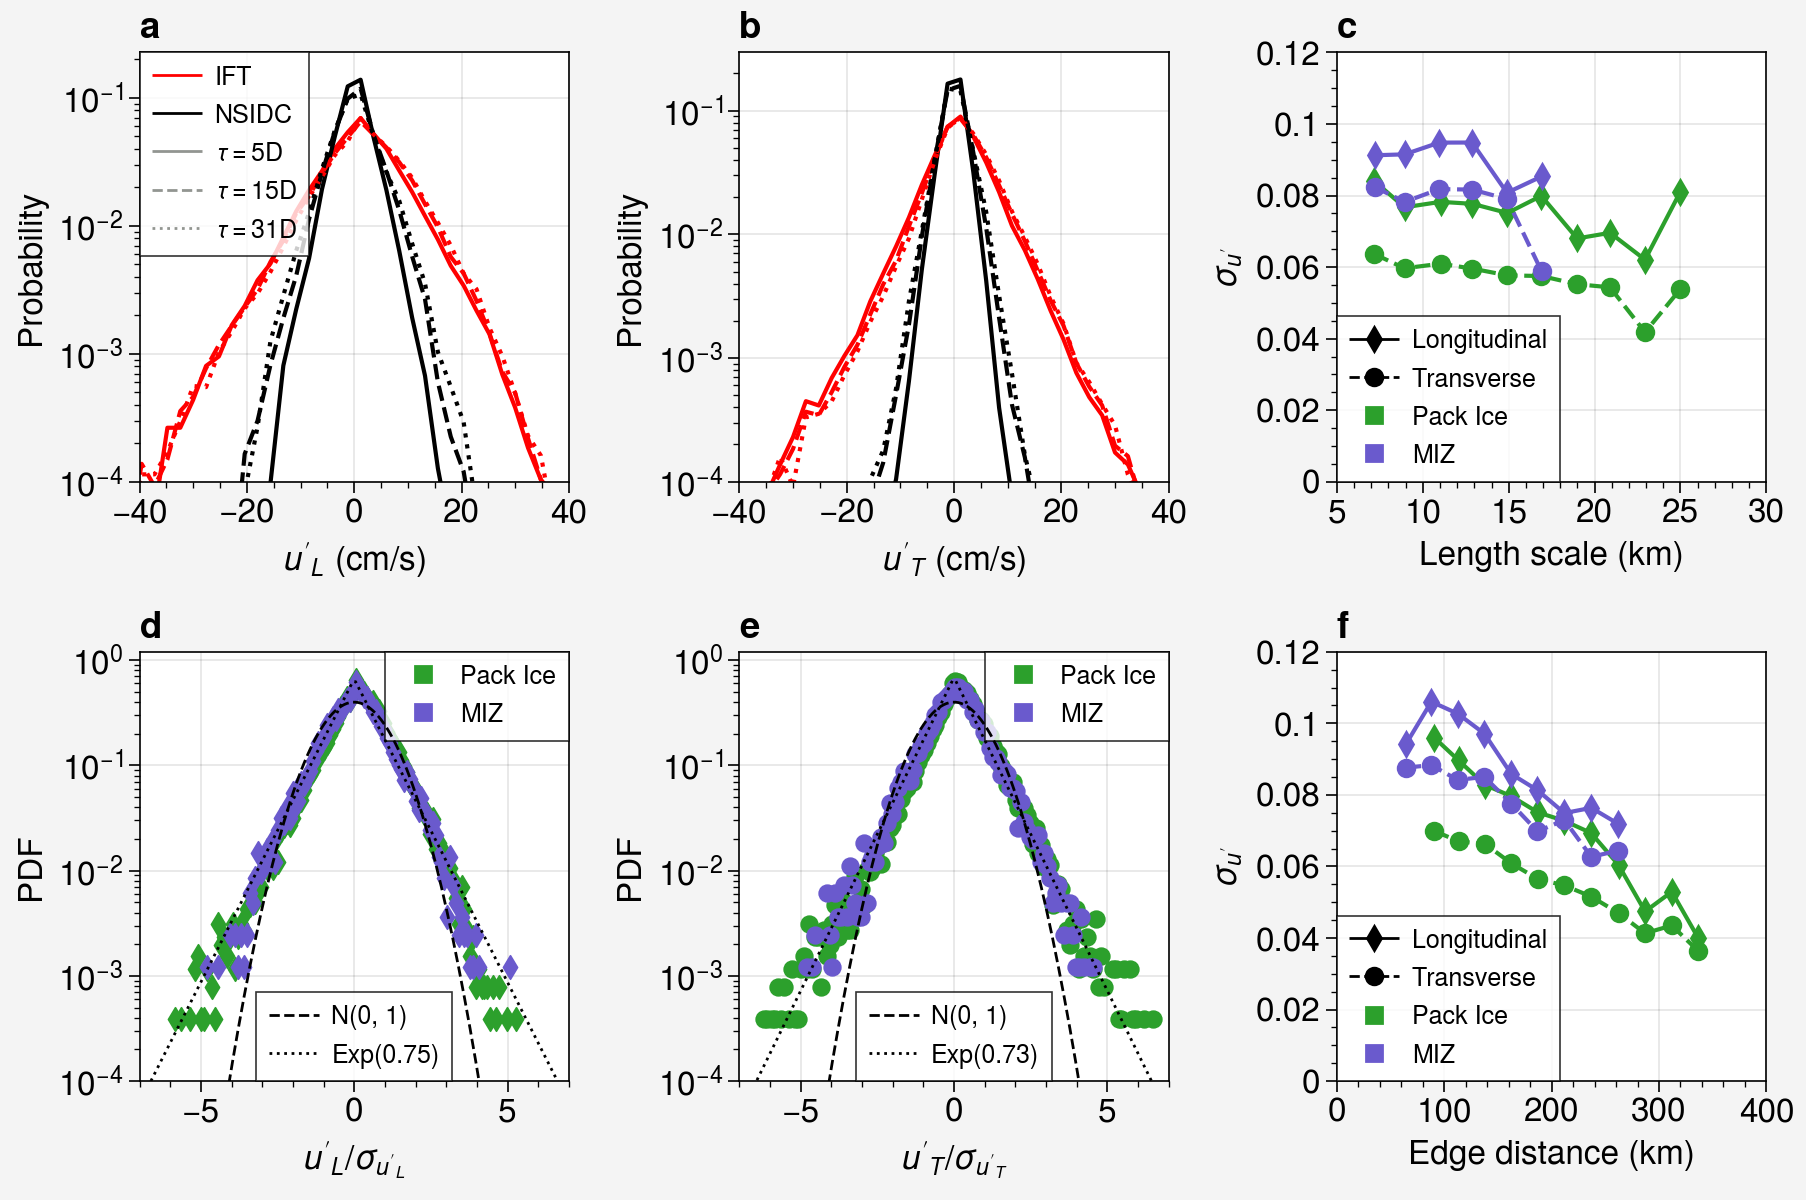

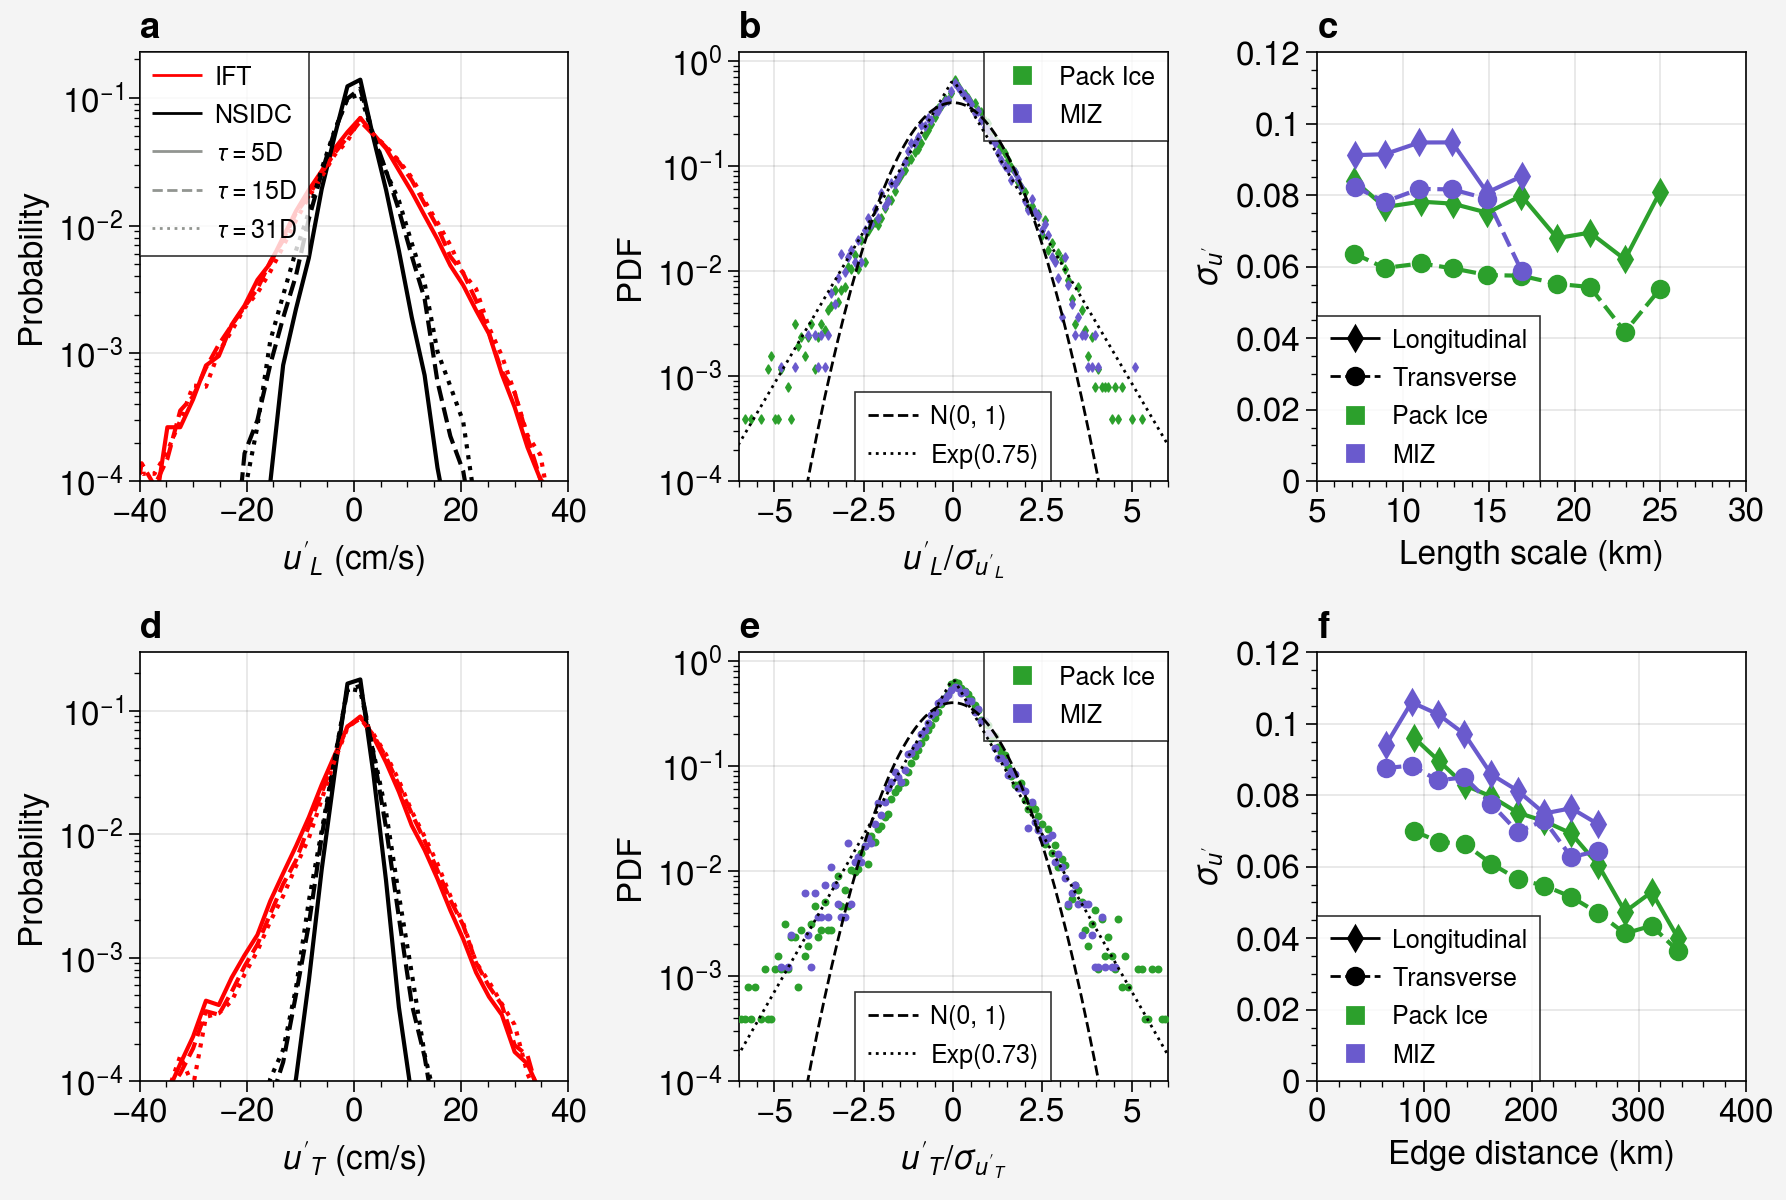

In [203]:
%run ../scripts/plot_fig_15_velocity_distribution.py

# Magnitude of the along-track and transverse components over time

In [205]:
df_comp = compute_along_across_components(comp, uvar='u', vvar='v',
                                    umean='u' + tau + '_nsidc',
                                    vmean='u' + tau + '_nsidc')

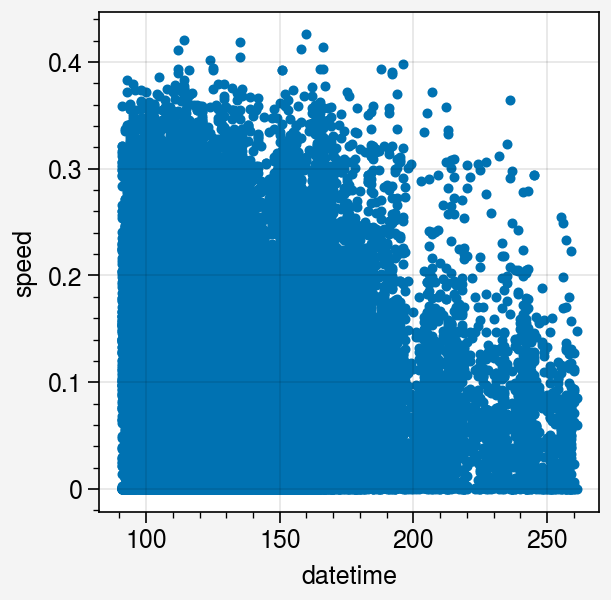

In [214]:
df_comp['U_along']
fig, ax = pplt.subplots()
ax.scatter(df_ift.datetime.dt.dayofyear, df_ift.speed, marker='.')

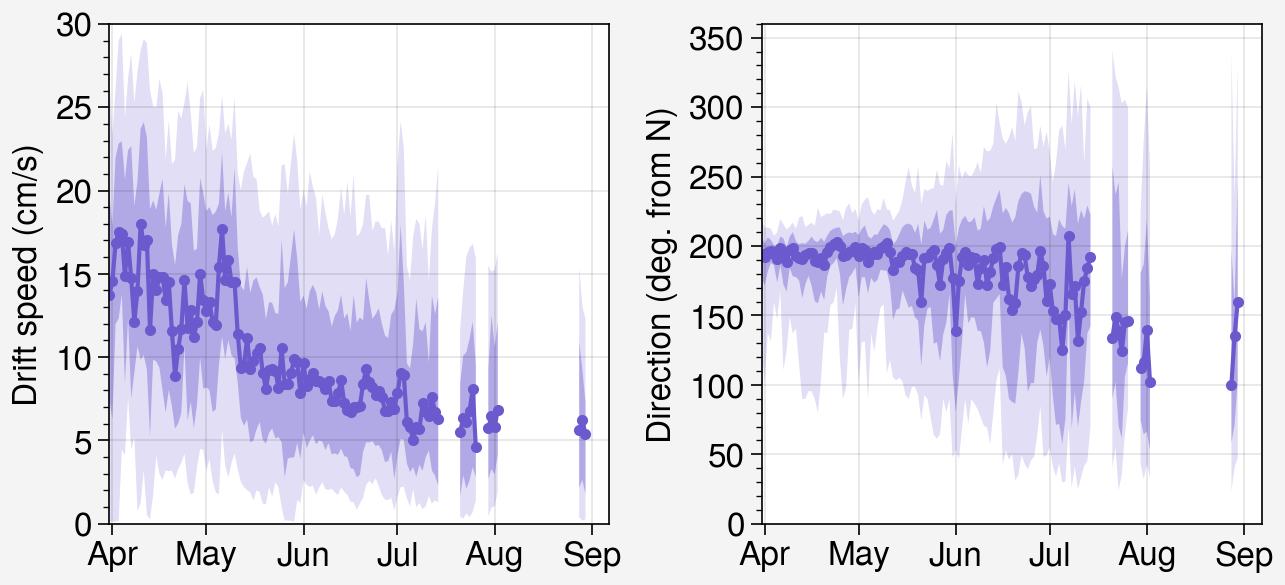

In [233]:
fig, axs = pplt.subplots(ncols=2, share=False)
idx = df_ift.speed.notnull()
df_ift['speed_cms'] = 100 * df_ift['speed']
df_ift['doy'] = df_ift.datetime.dt.dayofyear
ylims['bearing'] = (0, 360)
ylims['speed_cms'] = (0, 30)
for col, var in zip([0, 1],
                          ['speed_cms', 'bearing']):
    # shade data
    ax = axs[col]
    n = df_ift.loc[idx, [var, 'doy']].groupby('doy').count()
    med = df_ift.loc[idx, [var, 'doy']].groupby('doy').median().where(n > 50)
    p90 = df_ift.loc[idx, [var, 'doy']].groupby('doy').quantile(0.90).where(n > 50)
    p10 = df_ift.loc[idx, [var, 'doy']].groupby('doy').quantile(0.10).where(n > 50)
    p75 = df_ift.loc[idx, [var, 'doy']].groupby('doy').quantile(0.75).where(n > 50)
    p25 = df_ift.loc[idx, [var, 'doy']].groupby('doy').quantile(0.25).where(n > 50)
    ax.plot(med[var], fadedata=[p90[var], p10[var]],
            shadedata=[p75[var], p25[var]], marker='.', color='slateblue')
    ax.format(ylabel=var.replace('_', ' '),
              xlocator=dr.dayofyear,
              xformatter=[d.strftime('%b') for d in dr],
              xlabel='', fontsize=12, ylim=ylims[var])

axs[0].format(ylabel='Drift speed (cm/s)')
axs[1].format(ylabel='Direction (deg. from N)')
fig.save('../figures/presentations/drift_speed_dist.pdf', dpi=300)

# Add maps

In [ ]:

df_ift['L'] = df_ift['area_adj_km2']**0.5
df_ift['l_bin'] = np.digitize(df_ift['L'], bins=np.arange(0, 60, 5))
df_ift['l_center'] = [pd.Series(np.arange(2.5, 63, 5), index=np.arange(1, 14))[x] for x in df_ift['l_bin']]
df_ift.loc[:, ['l_bin', 'zeta']].groupby('l_bin').quantile([0.05, 0.1, 0.25, 0.5, 0.75, 0.90, 0.95])